#  03 — Uji Coba Model (3 Fitur: Accel + Gyro + BPM)

Prasyarat: `models/knn_model.pkl`, `models/scaler.pkl`, `models/bpm_medians.pkl` harus ada.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, StratifiedKFold

from config import FEATURES, TARGET, CLASSES, MODEL_PATH, SCALER_PATH, BPM_MED_PATH
from utils  import load_and_clean_dataset, impute_bpm, remove_outliers,\
                   normalize_features, encode_labels, impute_bpm_single, get_logger

logger = get_logger('notebook_03')
sns.set_theme(style='whitegrid')
print('Fitur:', FEATURES)

Fitur: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Load Model, Scaler, BPM Medians

In [2]:
model       = joblib.load(MODEL_PATH)
scaler      = joblib.load(SCALER_PATH)
bpm_medians = joblib.load(BPM_MED_PATH)

print(f'✅ Model   : K={model.n_neighbors}, metric={model.metric}, weights={model.weights}')
print(f'✅ Fitur   : {FEATURES}')
print(f'✅ BPM med : {bpm_medians}')

✅ Model   : K=19, metric=euclidean, weights=distance
✅ Fitur   : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
✅ BPM med : {'DUDUK': 78, 'BERJALAN': 90, 'BERLARI': 103, '_global': 84}


## 2. Prediksi Manual — Simulasi Nilai Sensor

Masukkan nilai accel_stddev (g), gyro_stddev (°/s), dan BPM untuk verifikasi.
BPM=0 akan diimputasi otomatis dengan median dari training data.

| Aktivitas | accel (g)   | gyro (°/s) | BPM        |
|-----------|-------------|------------|------------|
| Duduk     | 0.005–0.03  | 1–9        | 60–80      |
| Berjalan  | 0.04–0.12   | 10–38      | 80–110     |
| Berlari   | 0.13–0.45   | 40–200     | 120–180    |

In [3]:
def predict_activity(accel_std, gyro_std, bpm):
    """Prediksi dengan imputasi BPM otomatis jika bpm=0."""
    bpm_filled = impute_bpm_single(bpm, bpm_medians=bpm_medians)
    X = np.array([[accel_std, gyro_std, bpm_filled]])
    X_scaled = scaler.transform(X)
    pred  = model.predict(X_scaled)[0]
    proba = model.predict_proba(X_scaled)[0]
    return {
        'prediction':    pred,
        'confidence':    round(float(np.max(proba)), 4),
        'bpm_used':      int(bpm_filled),
        'probabilities': dict(zip(model.classes_, proba.round(4)))
    }

# Test cases: (accel, gyro, bpm, expected)
test_cases = [
    (0.010,  3.0,  70, 'DUDUK'),
    (0.020,  7.0,   0, 'DUDUK'),     # BPM=0 → diimputasi
    (0.070, 20.0,  90, 'BERJALAN'),
    (0.110, 35.0,   0, 'BERJALAN'),  # BPM=0 → diimputasi
    (0.200, 60.0, 140, 'BERLARI'),
    (0.350, 120.0,  0, 'BERLARI'),   # BPM=0 → diimputasi
]

print(f'{"accel":>8} {"gyro":>8} {"bpm":>5} {"bpm_used":>9} {"expected":>10} {"predicted":>10} {"conf":>8} {"OK?":>5}')
print('─'*72)
all_ok = True
for accel, gyro, bpm, expected in test_cases:
    r  = predict_activity(accel, gyro, bpm)
    ok = '✅' if r['prediction']==expected else '❌'
    if r['prediction']!=expected: all_ok=False
    print(f'{accel:8.3f} {gyro:8.1f} {bpm:5d} {r["bpm_used"]:9d} {expected:>10} '
          f'{r["prediction"]:>10} {r["confidence"]:8.3f} {ok}')
print('─'*72)
print('✅ Semua benar!' if all_ok else '⚠  Ada yang salah, pertimbangkan re-training.')

   accel     gyro   bpm  bpm_used   expected  predicted     conf   OK?
────────────────────────────────────────────────────────────────────────
   0.010      3.0    70        70      DUDUK      DUDUK    0.830 ✅
   0.020      7.0     0        84      DUDUK      DUDUK    0.790 ✅
   0.070     20.0    90        90   BERJALAN   BERJALAN    1.000 ✅
   0.110     35.0     0        84   BERJALAN   BERJALAN    0.693 ✅
   0.200     60.0   140       140    BERLARI    BERLARI    1.000 ✅
   0.350    120.0     0        84    BERLARI    BERLARI    1.000 ✅
────────────────────────────────────────────────────────────────────────
✅ Semua benar!


## 3. Load Dataset & Evaluasi Lengkap

In [4]:
CLEAN_PATH = '../data/processed/dataset_clean.csv'
df_raw  = load_and_clean_dataset(CLEAN_PATH)
df, _   = impute_bpm(df_raw, bpm_medians=bpm_medians, fit=False)
df      = remove_outliers(df)
df, _   = normalize_features(df, fit=False, scaler=scaler)

X      = df[FEATURES].values
y_true = df[TARGET].values
y_pred = model.predict(X)

df['predicted'] = y_pred
df['correct']   = df[TARGET] == df['predicted']
acc = df['correct'].mean()

print(f'Total sampel : {len(df)}')
print(f'Akurasi      : {acc*100:.2f}%')
print(f'Salah        : {(~df["correct"]).sum()} baris')
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Total sampel : 4570
Akurasi      : 98.34%
Salah        : 76 baris

              precision    recall  f1-score   support

       DUDUK     0.9737    0.9751    0.9744      1403
    BERJALAN     0.9754    0.9831    0.9793       889
     BERLARI     0.9925    0.9886    0.9905      2278

    accuracy                         0.9834      4570
   macro avg     0.9805    0.9823    0.9814      4570
weighted avg     0.9834    0.9834    0.9834      4570



## 4. Analisis Error — Sampel yang Salah Klasifikasi

In [5]:
wrong = df[~df['correct']]
print(f'Sampel salah: {len(wrong)}')
if len(wrong) > 0:
    print('\n=== Contoh salah (maks 10) ===')
    display(wrong[FEATURES + [TARGET, 'predicted']].head(10))
print('\n=== Error rate per kelas ===')
for cls in CLASSES:
    sub = df[df[TARGET]==cls]
    er  = 1 - sub['correct'].mean()
    print(f'  {cls:<10}: {er*100:.1f}%')

Sampel salah: 76

=== Contoh salah (maks 10) ===


,accel_stddev,gyro_stddev,bpm_filled,activity,predicted
32,0.188466,0.331823,0.328244,DUDUK,BERJALAN
106,0.016026,0.030656,0.290076,BERJALAN,DUDUK
238,0.123685,0.296045,0.488550,BERLARI,BERJALAN
268,0.159614,0.572712,0.412214,BERJALAN,BERLARI
327,0.271414,0.409479,0.366412,BERLARI,BERJALAN
454,0.383424,0.272445,0.549618,BERLARI,BERJALAN
468,0.435660,0.275225,0.832061,BERLARI,BERJALAN
490,0.408701,0.310424,0.572519,BERLARI,BERJALAN
511,0.369444,0.439820,0.465649,BERLARI,BERJALAN
561,0.476935,0.415919,0.732824,BERJALAN,BERLARI



=== Error rate per kelas ===
  DUDUK     : 1.1%
  BERJALAN  : 2.5%
  BERLARI   : 1.7%


## 5. Visualisasi Sampel Benar vs Salah (Accel vs Gyro)

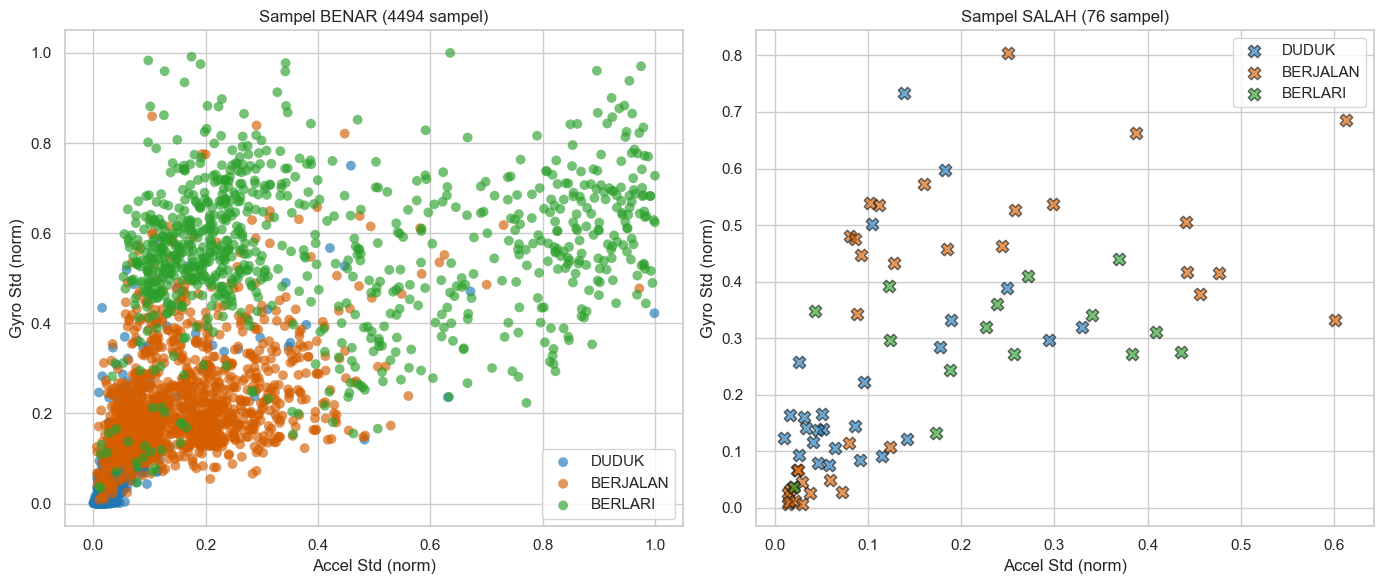

In [6]:
COLORS = ['#1F77B4','#D55E00','#2CA02C']
cmap   = dict(zip(CLASSES, COLORS))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (ax, title, subset) in enumerate([
    (axes[0], 'Sampel BENAR', df[df['correct']]),
    (axes[1], 'Sampel SALAH', df[~df['correct']])
]):
    for cls in CLASSES:
        s = subset[subset[TARGET]==cls]
        ax.scatter(s['accel_stddev'], s['gyro_stddev'],
                   c=cmap[cls], label=cls, alpha=0.65,
                   edgecolors='k' if i==1 else 'none',
                   s=50 if i==0 else 80, marker='o' if i==0 else 'X')
    ax.set_xlabel('Accel Std (norm)'); ax.set_ylabel('Gyro Std (norm)')
    ax.set_title(f'{title} ({len(subset)} sampel)')
    ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/error_analysis_3fitur.png', dpi=150); plt.show()

## 6. Visualisasi BPM vs Aktivitas (Scatter)

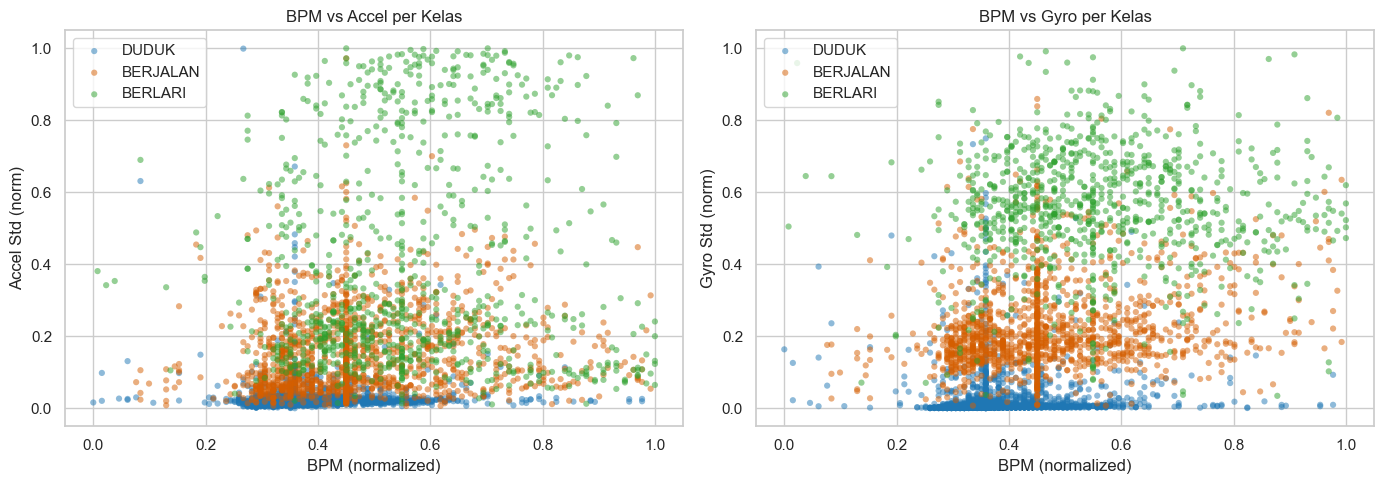

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ['#1F77B4','#D55E00','#2CA02C']
cmap   = dict(zip(CLASSES, COLORS))

# BPM filled vs Accel (normalized)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    axes[0].scatter(s['bpm_filled'], s['accel_stddev'], c=color, label=cls,
                    alpha=0.5, s=20, edgecolors='none')
axes[0].set_xlabel('BPM (normalized)'); axes[0].set_ylabel('Accel Std (norm)')
axes[0].set_title('BPM vs Accel per Kelas'); axes[0].legend()

# BPM filled vs Gyro (normalized)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    axes[1].scatter(s['bpm_filled'], s['gyro_stddev'], c=color, label=cls,
                    alpha=0.5, s=20, edgecolors='none')
axes[1].set_xlabel('BPM (normalized)'); axes[1].set_ylabel('Gyro Std (norm)')
axes[1].set_title('BPM vs Gyro per Kelas'); axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/bpm_scatter_3fitur.png', dpi=150); plt.show()

## 7. Learning Curve

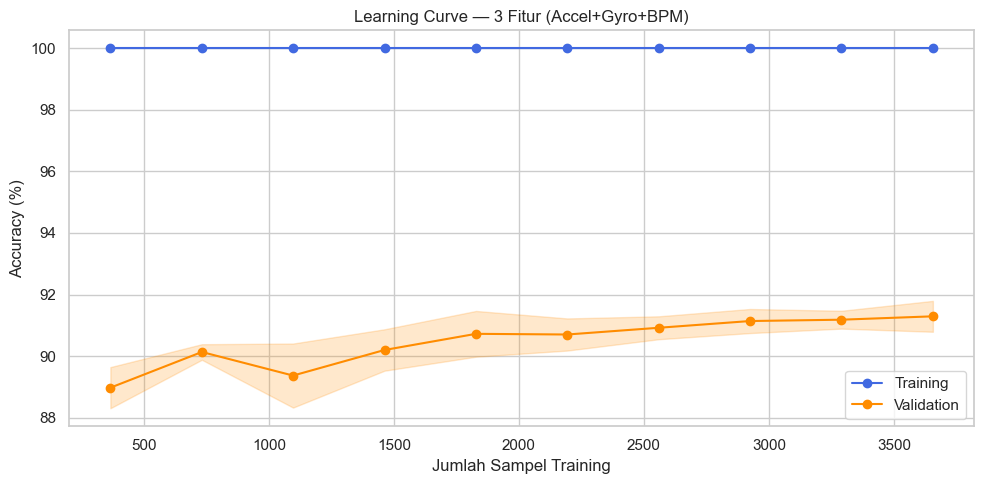

Gap train-val: 8.71%
✅ Model terlihat baik.


In [8]:
from sklearn.model_selection import learning_curve
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y_true, cv=kfold,
    train_sizes=np.linspace(0.1,1.0,10), scoring='accuracy', n_jobs=-1
)
tm, ts = train_scores.mean(1), train_scores.std(1)
vm, vs = val_scores.mean(1),   val_scores.std(1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, tm*100, 'o-', color='royalblue', label='Training')
plt.fill_between(train_sizes, (tm-ts)*100, (tm+ts)*100, alpha=0.2, color='royalblue')
plt.plot(train_sizes, vm*100, 'o-', color='darkorange', label='Validation')
plt.fill_between(train_sizes, (vm-vs)*100, (vm+vs)*100, alpha=0.2, color='darkorange')
plt.xlabel('Jumlah Sampel Training'); plt.ylabel('Accuracy (%)')
plt.title('Learning Curve — 3 Fitur (Accel+Gyro+BPM)')
plt.legend(); plt.tight_layout()
plt.savefig('../data/processed/learning_curve_3fitur.png', dpi=150); plt.show()

gap = tm[-1] - vm[-1]
print(f'Gap train-val: {gap*100:.2f}%')
if gap > 0.10: print('⚠  Kemungkinan overfitting.')
elif vm[-1] < 0.85: print('⚠  Akurasi rendah — tambah data.')
else: print('✅ Model terlihat baik.')

## 8. Ringkasan Akhir

In [9]:
print('='*57)
print('  RINGKASAN UJI COBA MODEL')
print('='*57)
print(f'  Algoritma : KNN (K={model.n_neighbors}, metric={model.metric})')
print(f'  Fitur     : {FEATURES}')
print(f'  Kelas     : {CLASSES}')
print(f'  Dataset   : {len(df)} sampel')
print(f'  Akurasi   : {acc*100:.2f}%')
print(f'  BPM med   : {bpm_medians}')
print('='*57)

  RINGKASAN UJI COBA MODEL
  Algoritma : KNN (K=19, metric=euclidean)
  Fitur     : ['accel_stddev', 'gyro_stddev', 'bpm_filled']
  Kelas     : ['DUDUK', 'BERJALAN', 'BERLARI']
  Dataset   : 4570 sampel
  Akurasi   : 98.34%
  BPM med   : {'DUDUK': 78, 'BERJALAN': 90, 'BERLARI': 103, '_global': 84}
